In [33]:
import numpy as np
import pyvista as pv
from process_data import extract_data
pv.start_xvfb()
pv.set_jupyter_backend('static')
from scipy.spatial.transform import Rotation


In [31]:
def quat_to_eulerxyz(quaternion):
    return Rotation.from_quat(quaternion).as_euler('xyz',degrees=True)

def eulerxyz_to_quat(xyz_degtuple):
    return Rotation.from_euler('xyz',xyz_degtuple,degrees=True).as_quat()

In [21]:
def visualize_point_cloud(pc,a, point_size=5):
    cloud = pv.PolyData(pc)
    plotter = pv.Plotter()
    plotter.add_points(cloud, point_size=point_size, color="red")
    start = np.array([a[0], 0, pc[:, 2].max() + 1.0])
    # Direction: pointing down in z (negative z direction)
    direction = np.array([0, 0, -1])
    # Add arrow
    plotter.add_arrows(start, direction, mag=1.0, color="blue")
    plotter.show_axes()
    plotter.show()


def visualize_point_diff(pc1, pc2, point_size=5):
    # cloud = pv.PolyData(pc)
    plotter = pv.Plotter()
    # plotter.add_points(cloud, point_size=point_size, color="red")
    start = pc1
    direction = pc2 - pc1
    # Add arrow
    plotter.add_arrows(start, direction, mag=1.0, color="blue")
    plotter.show_axes()
    plotter.show()

def visualize_point_diff1(pc1, pc2, point_size=5):
    plotter = pv.Plotter(shape=(1, 3))  # 1 row, 3 columns
    
    start = pc1
    direction = pc2 - pc1
    
    # View 1: Looking down Z (top view)
    plotter.subplot(0, 0)
    plotter.add_arrows(start, direction, mag=1.0, color="blue")
    plotter.show_axes()
    plotter.view_xy()  # Look down Z axis
    plotter.add_text("Top View (Z)", font_size=10)
    
    # View 2: Looking down X (side view)
    plotter.subplot(0, 1)
    plotter.add_arrows(start, direction, mag=1.0, color="blue")
    plotter.show_axes()
    plotter.view_yz()  # Look down X axis
    plotter.add_text("Side View (X)", font_size=10)
    
    # View 3: Looking down Y (front view)
    plotter.subplot(0, 2)
    plotter.add_arrows(start, direction, mag=1.0, color="blue")
    plotter.show_axes()
    plotter.view_xz()  # Look down Y axis
    plotter.add_text("Front View (Y)", font_size=10)
    
    plotter.show()

In [3]:
total_points = 2048
lines = 100
db_path1 = '/local/scratch/groves/jax-forgeRL/jax-forge/data/tianhong_data/noisy_cogging.db'
db_path2 = '/local/scratch/groves/jax-forgeRL/jax-forge/data/tianhong_data/RL_random_cogging.db'


In [4]:
c_t1, c_tp11, s1, p1, r1, series_lengths1, series_ids1 = extract_data(db_path1, total_points, lines)
c_t2, c_tp12, s2, p2, r2, series_lengths2, series_ids2 = extract_data(db_path2, total_points, lines)
# group_df = extract_data(db_path2, total_points, lines)
# group_df.head()



Processing series:   0%|          | 0/4 [00:00<?, ?it/s]

Processing series: 100%|██████████| 1/1 [00:06<00:00,  6.17s/it]


In [5]:
c_t = np.vstack((c_t1, c_t2))
c_tp1 = np.vstack((c_tp11, c_tp12))
s = np.vstack((s1, s2))
p = np.vstack((p1, p2))
r = np.vstack((r1,r2))
series_lengths = series_lengths1 + series_lengths2
series_ids = series_ids1 + series_ids2

# group_df = extract_data(db_path, total_points, lines)

# group_df.head()

In [6]:
print(c_t.shape), print(c_tp1.shape), print(s.shape), print(p.shape), print(r.shape)
print(series_lengths)
print(series_ids)

(195, 2048, 3)
(195, 2048, 3)
(195, 1)
(195, 3)
(195, 4)
[11, 53, 10, 22, 99]
['3abff69b-8adf-4ce8-8492-b07325c47861', '72f102a6-9d91-490e-8a81-0c64ef0b9945', 'd49fd4ab-711f-483d-a18c-8c63374ae643', '71784ea3-b0a2-4c9b-8a27-dc0abf52af68', '94b9ec21-6892-44b2-b404-7a4629df0feb']


In [34]:
quat_to_eulerxyz(r[25])

array([70.73723121,  0.        ,  0.        ])

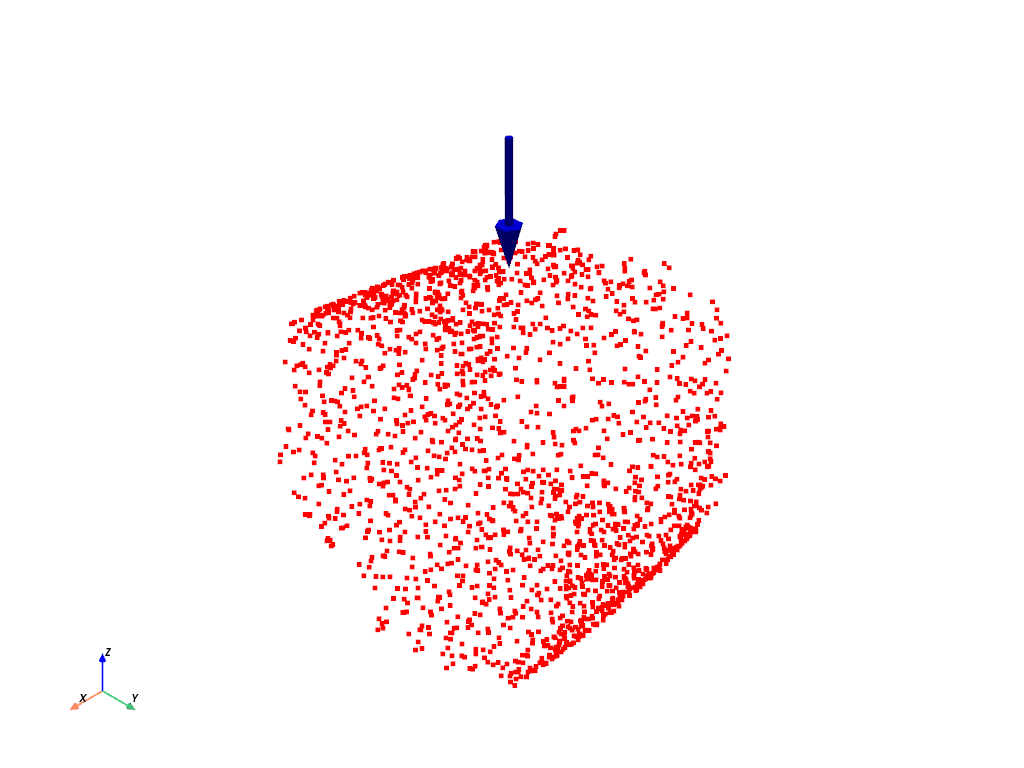

In [8]:
visualize_point_cloud(c_t[25],a=-p[25], point_size=5)
# import matplotlib.pyplot as plt
# fig = plt.figure()
# ax = fig.add_subplot(projection = '3d')
# ax.scatter(xs=c_t[25][:,0],ys=c_t[25][:,1],zs=c_t[25][:,2], s=2)
# plt.show()

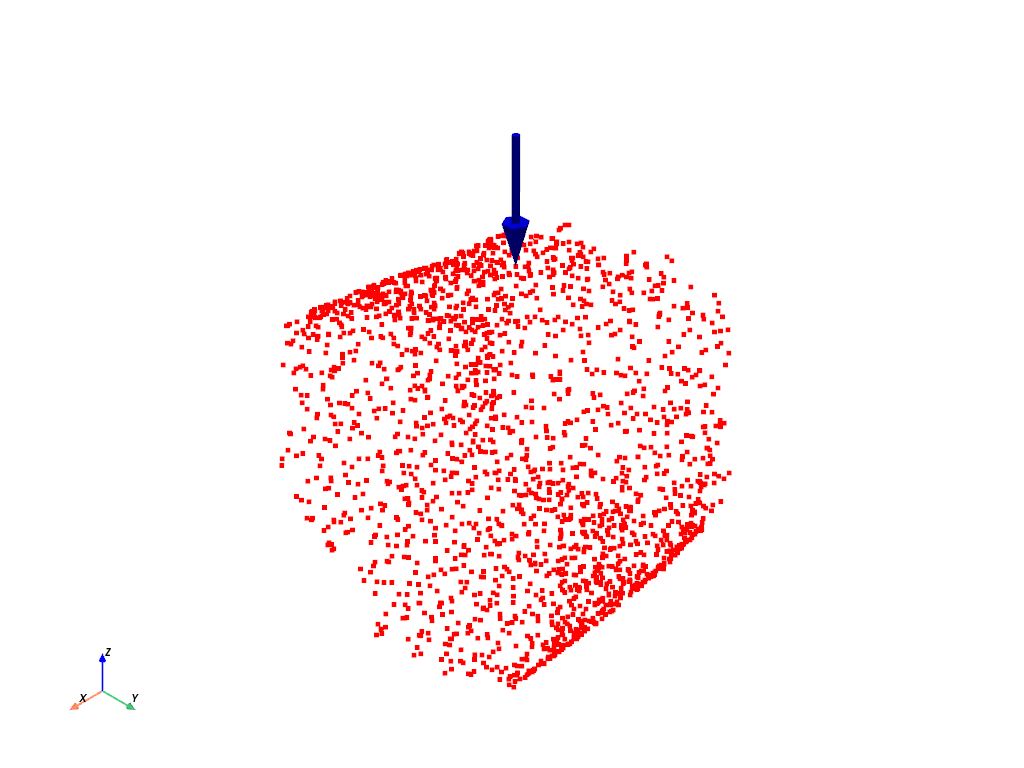

In [9]:
visualize_point_cloud(c_tp1[25],a=-p[25], point_size=5)

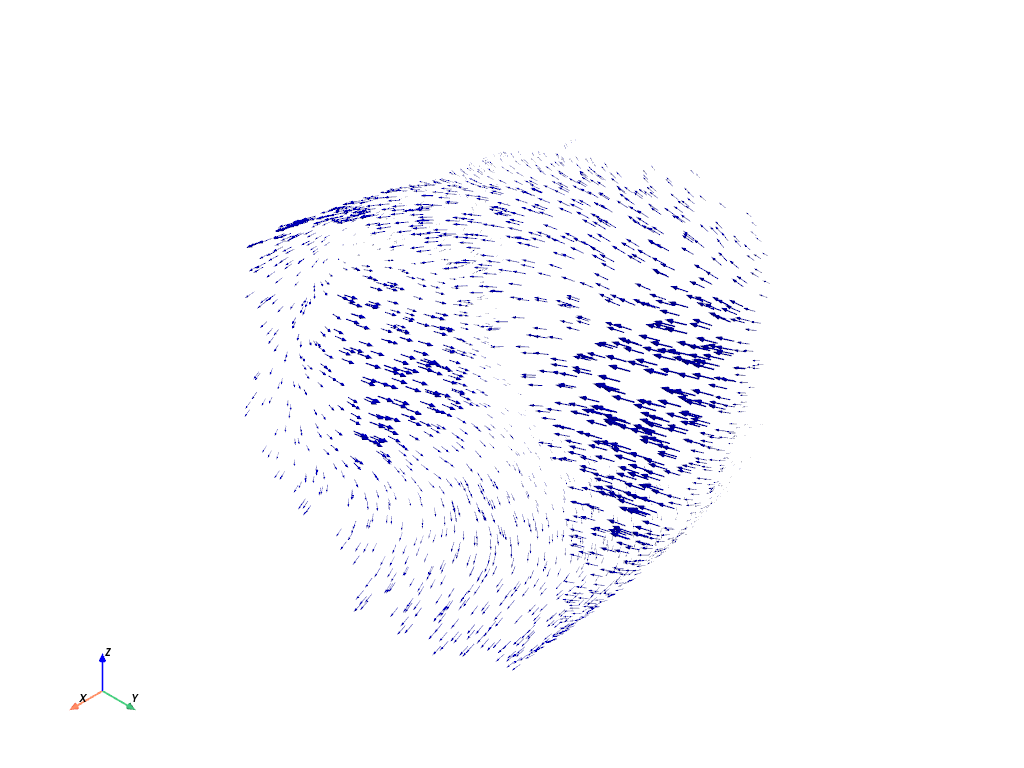

In [ ]:
visualize_point_diff(c_t[26],c_tp1[26])


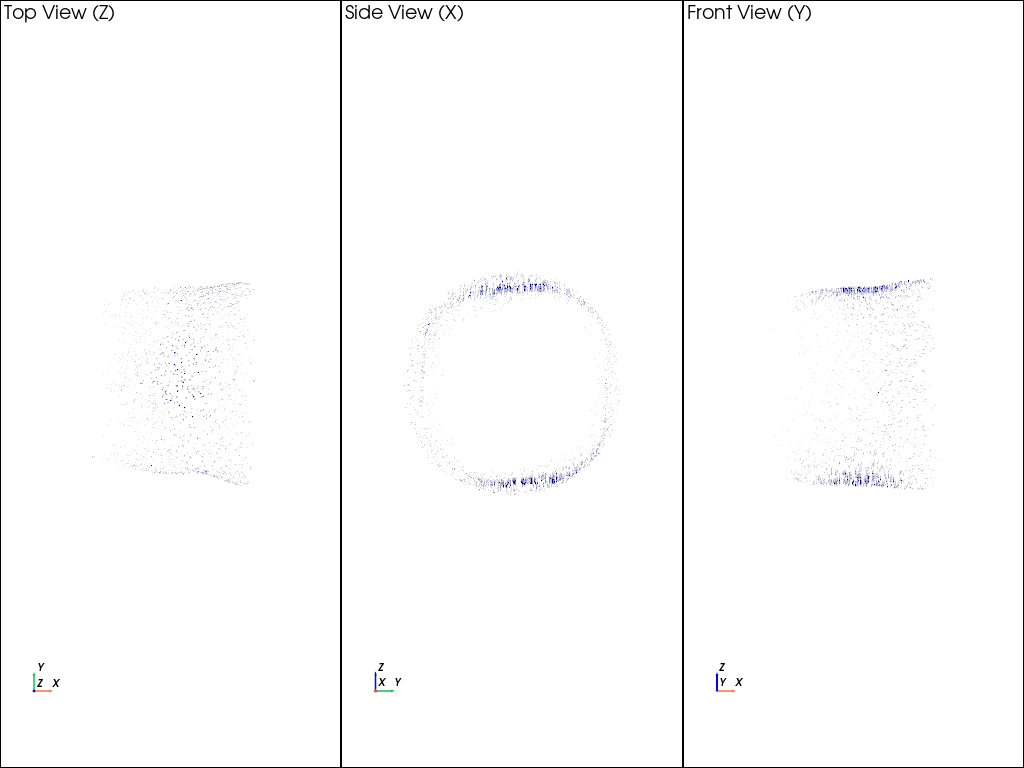

In [26]:

visualize_point_diff1(c_tp1[40],c_t[40])


In [11]:
np.savez('./test_comb_med_neg.npz', coords_t=c_t, coords_tp1=c_tp1, steps=s, positions=p, rotations=r, series_lengths=np.array(series_lengths))